In [25]:
"""
Critical Batch Size and GNS Joint Plot (CV/CIFAR)

Publication-ready plotting.
Overlays CBS (lighter dashed lines) and GNS (solid lines) on the same plot.
Reads data from cv.parquet (single seed).
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import numpy as np

%matplotlib inline

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

SINGLE_COL = 3.25

WIDTH_COLORS = {
    1: '#4477AA',
    2: '#EE6677',
    4: '#228833',
}
WIDTH_MARKERS = {
    1: 'o',
    2: 's',
    4: '^',
}

In [ ]:
# ============================================================================
# Configuration
# ============================================================================
WIDTHS = [1, 2, 4]
# Effective batch sizes as stored in cv.parquet
BATCH_SIZES = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
LEARNING_RATES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

X_MIN = 0.0005
X_MAX = 1.0

LOSS_VALUES = {
    1: [1.0, 0.5, 0.25, 0.1, 0.05, 0.025],
    2: [1.0, 0.5, 0.25, 0.1, 0.05, 0.025],
    4: [1.0, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.002, 0.001],
}

BASE_SMOOTHING_WINDOW = 1024  # EWM span base (CBS)
GNS_SMOOTHING_WINDOW  = 32    # Centered rolling window (GNS)
CBS_SPEEDUP_THRESHOLD = 1.0 / 1.2

GNS_CONFIGS = {
    1: [{'bs': 4096, 'lr': 1e-3}],
    2: [{'bs': 4096, 'lr': 1e-3}],
    4: [{'bs': 4096, 'lr': 1e-3}],
}

In [ ]:
# ============================================================================
# Load parquet
# ============================================================================
# ADAPT THIS TO THE FILEPATH OF YOUR PARQUET FILE #
df = pd.read_parquet('cv.parquet')
df['width'] = df['width'].astype(int)
print('Shape:', df.shape)
df.head(2)

Shape: (11232540, 14)


,iteration,gns,gns_norm,gns_var,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,width,batch_size,lr,samples_seen
0,0,NaN,NaN,NaN,NaN,NaN,2.296875,0.1,2.296875,0.1,1,4096,0.000001,0
1,11,1207.800391,2.987038,3607.745443,2.299751,NaN,NaN,NaN,NaN,NaN,1,4096,0.000001,45056


In [28]:
# ============================================================================
# Helper functions
# ============================================================================
_cbs_cache, _gns_cache = {}, {}


def get_run(width, bs, lr):
    return df[
        (df['width']      == width) &
        (df['batch_size'] == bs) &
        (df['lr']         == lr)
    ]


def load_for_cbs(width, bs, lr):
    key = (width, bs, lr)
    if key in _cbs_cache:
        return _cbs_cache[key]

    subset = get_run(width, bs, lr)
    subset = subset[subset['train_loss'].notna()].copy()

    if len(subset) == 0:
        _cbs_cache[key] = None
        return None

    span = max(5, int(BASE_SMOOTHING_WINDOW / np.sqrt(bs)))
    subset['loss_smoothed'] = subset['train_loss'].ewm(span=span, adjust=False).mean()
    _cbs_cache[key] = subset
    return subset


def load_for_gns(width, bs, lr):
    key = (width, bs, lr)
    if key in _gns_cache:
        return _gns_cache[key]

    subset = get_run(width, bs, lr)
    subset = subset[subset['gns'].notna()].copy()

    if len(subset) == 0:
        _gns_cache[key] = None
        return None

    subset['loss_smoothed'] = subset['train_loss'].rolling(GNS_SMOOTHING_WINDOW, center=True).mean()
    subset['gns_smoothed']  = subset['gns'].rolling(GNS_SMOOTHING_WINDOW, center=True).mean()
    subset = subset.dropna(subset=['loss_smoothed', 'gns_smoothed'])
    _gns_cache[key] = subset
    return subset

In [29]:
# ============================================================================
# Compute CBS for all widths
# ============================================================================
def find_critical_batch_size(target_loss, width):
    results = []

    for bs in BATCH_SIZES:
        for lr in LEARNING_RATES:
            run = load_for_cbs(width, bs, lr)
            if run is None:
                continue

            mask = run['loss_smoothed'] <= target_loss
            if mask.any():
                first_idx = mask.idxmax()
                results.append({
                    'batch_size': bs,
                    'lr': lr,
                    'samples': run.loc[first_idx, 'samples_seen'],
                })

    if not results:
        return np.nan

    res = pd.DataFrame(results)
    best = []
    for bs in BATCH_SIZES:
        sub = res[res['batch_size'] == bs]
        if len(sub):
            best.append(sub.loc[sub['samples'].idxmin()])

    if not best:
        return np.nan

    best_df = pd.DataFrame(best).sort_values('batch_size').reset_index(drop=True)
    min_samples = best_df.iloc[0]['samples']
    best_df['speedup'] = min_samples / best_df['samples']

    for i in range(1, len(best_df)):
        if best_df.iloc[i]['speedup'] < CBS_SPEEDUP_THRESHOLD:
            bs1, bs2 = best_df.iloc[i-1]['batch_size'], best_df.iloc[i]['batch_size']
            s1,  s2  = best_df.iloc[i-1]['speedup'],    best_df.iloc[i]['speedup']
            t = (CBS_SPEEDUP_THRESHOLD - s1) / (s2 - s1)
            return np.exp(np.log(bs1) + (np.log(bs2) - np.log(bs1)) * t)

    return best_df.iloc[-1]['batch_size']


print('Computing critical batch sizes for all widths...')
cbs_data = {}
for width in WIDTHS:
    print(f'  Width {width}...', end=' ')
    cbs_data[width] = [find_critical_batch_size(loss, width) for loss in LOSS_VALUES[width]]
    print(cbs_data[width])

Computing critical batch sizes for all widths...
  Width 1... [203.418190446491, 207.8373889752669, 307.47247604805403, 316.6433708590269, 201.95883536889883, 239.2189075814784]
  Width 2... [178.11679231271265, 263.3917876708283, 287.9393480056544, 274.3304423969139, 261.7908248392563, 664.6705803337304]
  Width 4... [95.28790799099168, 134.44171645071702, 243.8826225766888, 368.44387675211544, 411.47885080913073, 281.4479269772419, 609.0786371326435, 445.0152793392719, 389.3216667757345]


In [30]:
# ============================================================================
# Load GNS data for all widths
# ============================================================================
print('Loading GNS data...')
gns_data = {}
for width, configs in GNS_CONFIGS.items():
    gns_data[width] = []
    for cfg in configs:
        run = load_for_gns(width, cfg['bs'], cfg['lr'])
        if run is not None:
            gns_data[width].append(run)
            print(f'  Width {width}: loaded GNS bs={cfg["bs"]} lr={cfg["lr"]}')
        else:
            print(f'  Width {width}: no data for bs={cfg["bs"]} lr={cfg["lr"]}')

Loading GNS data...
  Width 1: loaded GNS bs=4096 lr=0.001
  Width 2: loaded GNS bs=4096 lr=0.001
  Width 4: loaded GNS bs=4096 lr=0.001


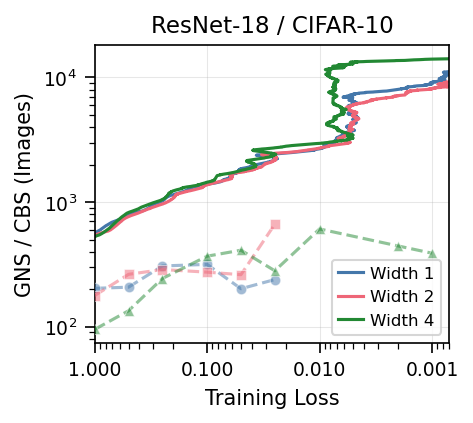

In [31]:
# ============================================================================
# Create joint CBS + GNS plot
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(SINGLE_COL, SINGLE_COL * 0.9))

# GNS (solid lines)
for width in WIDTHS:
    for run in gns_data.get(width, []):
        mask = (run['loss_smoothed'] >= X_MIN) & (run['loss_smoothed'] <= X_MAX)
        r = run[mask]
        if len(r):
            ax.plot(r['loss_smoothed'], r['gns_smoothed'],
                    color=WIDTH_COLORS[width], label=f'Width {width}', zorder=2)

# CBS (dashed lines with markers)
for width in WIDTHS:
    pairs = [(l, c) for l, c in zip(LOSS_VALUES[width], cbs_data[width]) if not np.isnan(c)]
    if pairs:
        losses, vals = zip(*pairs)
        ax.plot(losses, vals,
                marker=WIDTH_MARKERS[width], color=WIDTH_COLORS[width],
                linestyle='--', alpha=0.5,
                markeredgecolor='white', markeredgewidth=0.5, zorder=3)

ax.set_xlabel('Training Loss')
ax.set_ylabel('GNS / CBS (Images)')
ax.set_title('ResNet-18 / CIFAR-10', fontweight='medium')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.0007, X_MAX)
ax.invert_xaxis()

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)
ax.tick_params(axis='x', which='major', length=5)
ax.tick_params(axis='x', which='minor', length=3)
ax.tick_params(axis='y', which='major', length=5)
ax.tick_params(axis='y', which='minor', length=3)

ax.legend(loc='lower right', ncol=1, columnspacing=0.8,
          handlelength=1.5, handletextpad=0.4)

fig.tight_layout()
plt.show()

In [32]:
# ============================================================================
# Save plot
# ============================================================================
output_base = 'cbs_gns_joint_cv'
for fmt in ['pdf', 'png']:
    fig.savefig(f'{output_base}.{fmt}', format=fmt, pad_inches=0.02,
                dpi=300 if fmt == 'png' else None)
    print(f'Saved: {output_base}.{fmt}')

plt.close(fig)
print('Done!')

Saved: cbs_gns_joint_cv.pdf
Saved: cbs_gns_joint_cv.png
Done!
